In [1]:
%cd ..

C:\Users\daanw\PycharmProjects\BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from project.models import EDMEvelynn
from project.util.data import ReplayMemoryData
from project.util.transforms import CastTo

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: cuda


In [4]:
DATA = os.path.join("checkpoints", "memory", "AdamW25e5.pt")
CHECKPOINT = os.path.join("checkpoints", "diffusion", "test.pt")

In [5]:
MODEL = "edm2"

In [6]:
TARGET = 0
BATCH_SIZE = 32
RESOLUTION = 84
IN_CHANNELS = 4
OUT_CHANNELS = 3
START_CHANNELS = 64
NUM_RES_BLOCKS = 2
CHANNEL_MULTIPLIERS = (1, 2,)
ATTENTION_RESOLUTIONS = (21,)
LR = 2e-3
DROPOUT = 0.13

In [7]:
transform = transforms.Compose([
    CastTo(torch.float),
    transforms.Normalize(0.5, 0.5),
])

In [8]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

Image shape: torch.Size([84, 84])


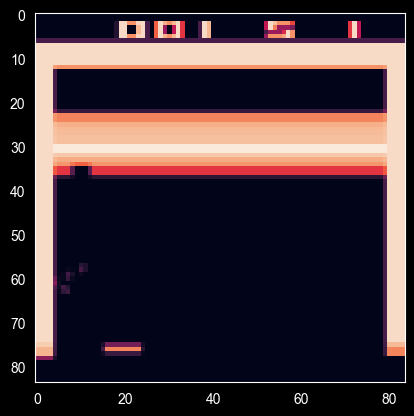

In [9]:
image = (data[50] / 255).mean(dim=0)
print(f"Image shape: {image.shape}")
plt.imshow(image)
plt.grid(None)
plt.show()

In [10]:
model = EDMEvelynn(
    img_resolution=RESOLUTION,
    img_channels=IN_CHANNELS,
    start_channels=START_CHANNELS,
    channel_mult=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_RES_BLOCKS,
    attention_resolutions=ATTENTION_RESOLUTIONS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    lr=LR,
    network="edm2"
).to(device)

In [11]:
if os.path.exists(CHECKPOINT):
    model.load(CHECKPOINT)
    print("Loaded checkpoint!")

In [ ]:
model.train(10, loader)

Epoch 1: 100%|██████████| 157/157 [12:18<00:00,  4.70s/it]


Loss: 10381.45326


Epoch 2:  10%|▉         | 15/157 [01:10<11:09,  4.71s/it]

In [ ]:
model.save(CHECKPOINT)

In [ ]:
x = model.heun_sampler(16).to("cpu")
x = (x + 1) / 2

In [ ]:
fig, axis = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True)
for i in range(4):
    for j in range(4):
        axis[i, j].imshow(x[i * 4 + j].permute(1, 2, 0).clip(0, 1))
        axis[i, j].grid(None)